In [19]:
import json
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DIR_REPO = Path.cwd().parents[1]
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))
print(DIR_REPO)

d:\WORK\Salvador\repo\A1_OUinp


In [3]:
EXP_LABEL = (
    'batch_rxbkg_unconn_state1_mech1/net_inpsur_rsweep_newsec_var_seed_pre/'
    'exp_pre_L2_post_L2_nseed_5_npre_5_t_5.0_20.0_tri_t0_5000_T_7500_rmax_50_ictrl_wmult_0.25_ee_0.5'
)
CFG_PARAM_FIELDS = {'pop_pre': 'pop_pre', 'seed': 'seed_main'}

# Time interval of spike extraction
spike_t_limits = (1, None)

# Params of rate dynamics
dt_bin = 2e-3
tau_smooth = 10e-3

# Per-dimension chunk sizes for the rate dynamics nc-file
rate_chunks = {'pop_pre': 1, 'seed': 1}

dirpath_exp = DIR_REPO / 'exp_results' / EXP_LABEL
dirpath_cfg = dirpath_exp / 'cfg'
dirpath_work = dirpath_exp / 'combined'
dirpath_cache = dirpath_work / 'data_proc'
dirpath_res = dirpath_work / 'results'

os.makedirs(dirpath_cache, exist_ok=True)
os.makedirs(dirpath_res, exist_ok=True)

In [7]:
rates_cache_path = dirpath_cache / f'rates_dt_{dt_bin}_tau_{tau_smooth}.nc'

rates_xr = xr.open_dataarray(rates_cache_path, chunks={})
rates_xr

<xarray.DataArray (pop_pre: 5, seed: 5, pop: 7, time: 9500)>
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(5, 5, 7, 9500), dtype=float64, chunksize=(5, 5, 7, 9500), chunktype=numpy.ndarray>
Coordinates:
  * pop_pre  (pop_pre) object 'IT2' 'NGF2' 'PV2' 'SOM2' 'VIP2'
  * seed     (seed) int64 1000 1001 1002 1003 1004
  * pop      (pop) object 'IT2' 'PV2' 'SOM2' 'VIP2' 'NGF2' 'ITP4frz' 'IT2frz'
  * time     (time) float64 1.0 1.002 1.004 1.006 ... 19.99 19.99 20.0 20.0
    job_id   (pop_pre, seed) int64 dask.array<chunksize=(5, 5), meta=np.ndarray>
Attributes:
    time_units:  s
    cache_info:  __json__:{"cache_id":"e2c98e4c6253","cache_version":1,"param...
    proc_steps:  __json__:[{"name":"collect_batch_rates_from_spike_data","par...

In [23]:
# Read first config
fname_job_cfg_templ = 'cfg_00000_*.json'
cfg_paths = sorted(dirpath_cfg.glob(fname_job_cfg_templ))
with cfg_paths[0].open('r', encoding='utf-8') as f:
    cfg0 = json.load(f)['simConfig']

# Target rates
r_target = cfg0['target_rates']

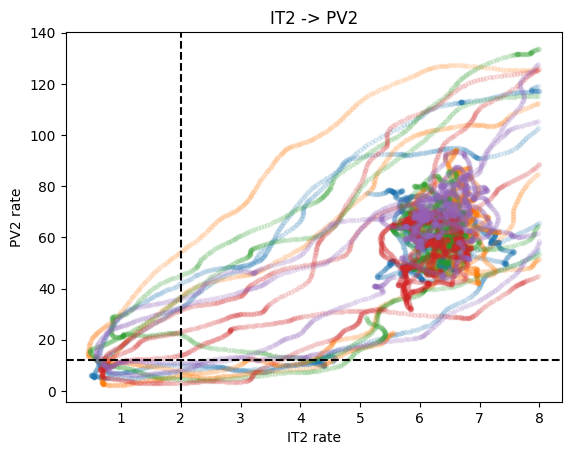

In [29]:
pop_pre = 'IT2'

pops_post = [pop for pop in rates_xr.pop.values if 'frz' not in pop]

R_pre = rates_xr.sel(pop_pre=pop_pre, pop=f'{pop_pre}frz').compute()
R_post = rates_xr.sel(pop_pre=pop_pre, pop=pops_post).compute()

# Moving-average smoothing over time
smooth_win_s = 0.2
smooth_win_n = max(1, int(round(smooth_win_s / dt_bin)))
R_pre_sm = R_pre.rolling(time=smooth_win_n, center=True, min_periods=1).mean()
R_post_sm = R_post.rolling(time=smooth_win_n, center=True, min_periods=1).mean()

mask = R_pre_sm < 8
R_pre_sm = R_pre_sm.where(mask)
R_post_sm = R_post_sm.where(mask)

pop_post = 'PV2'

r0_pre = r_target[pop_pre]
r0_post = r_target[pop_post]

plt.figure()
for seed in R_pre_sm.seed.values:
    plt.plot(R_pre_sm.sel(seed=seed),
            R_post_sm.sel(seed=seed).sel(pop=pop_post),
            '.', alpha=0.1)
plt.axhline(r0_post, color='k', linestyle='--')
plt.axvline(r0_pre, color='k', linestyle='--')
plt.xlabel(f'{pop_pre} rate')
plt.ylabel(f'{pop_post} rate')
plt.title(f'{pop_pre} -> {pop_post}')
plt.show()

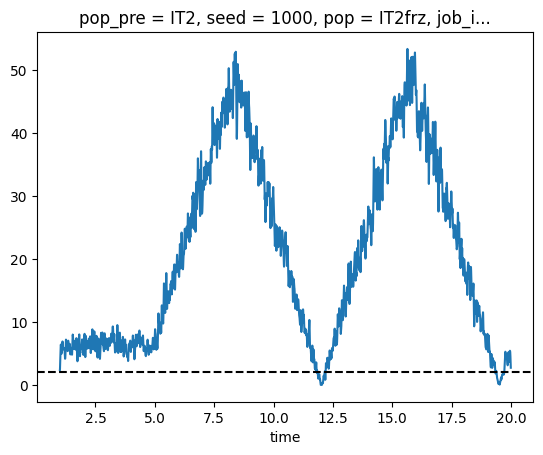

In [39]:
pop_dyn = 'IT2'
pop_pre = 'IT2'
R_pre = rates_xr.sel(pop_pre=pop_dyn, pop=f'{pop_pre}frz').isel(seed=0).compute()
r0_pre = r_target[pop_pre]

R_pre.plot()
plt.axhline(r0_pre, color='k', linestyle='--')